# Accumulated Local Effects (ALE) Plots

## Overview

ALE plots are a bias-corrected alternative to PDPs for datasets with correlated features. Where PDPs marginalise over the full distribution of other features — creating unrealistic combinations — ALE computes local effects within narrow intervals of the target feature, using only observations that actually have values in that range.

**ALE vs. PDP construction:**

| | PDP | ALE |
|---|---|---|
| Method | Average predictions across all data for each x | Average local differences within narrow intervals |
| Correlated features | ❌ Extrapolates to unrealistic combinations | ✓ Stays within observed data distribution |
| Interpretation | Average marginal prediction | Accumulated local effect relative to mean |
| Speed | Slower (n × grid predictions) | Faster (local averages) |
| Y-axis | Predicted response | Effect relative to mean prediction |

**When PDPs mislead:** If nitrate and phosphorus are correlated (r=0.85), the PDP for nitrate evaluates at low nitrate + high phosphorus (never observed in training data). ALE avoids this by conditioning on the local neighbourhood of each feature value.

**ALE y-axis:** ALE values are centred so they sum to zero. An ALE of +2 at x=8 means: for observations near x=8, the feature increases predicted richness by ~2 units relative to the average effect across all values.

---

## Setup

In [7]:
library(tidyverse)
library(ggplot2)
library(ranger)
library(iml)           # FeatureEffect() — ALE, PDP, ICE
library(pdp)           # partial() for PDP comparison
library(patchwork)

set.seed(42)

n <- 500

# ── Correlated predictors: the key scenario where ALE outperforms PDP ─────────
nitrate    <- runif(n, 1, 10)
phosphorus <- 0.85 * nitrate + rnorm(n, 0, 0.6)   # r ≈ 0.90 with nitrate
water_qual <- 9 - 0.55 * nitrate + rnorm(n, 0, 0.9)
elevation  <- rnorm(n, 200, 80)

ale_data <- tibble(
  nitrate, phosphorus, water_qual, elevation,
  richness = round(
    30 - 2.0 * nitrate - 0.5 * phosphorus + 1.4 * water_qual +
    0.01 * elevation + rnorm(n, 0, 2.5)
  )
)

cat(sprintf("Cor(nitrate, phosphorus): %.3f\n",
            cor(ale_data$nitrate, ale_data$phosphorus)))

# Train random forest
rf_fit <- ranger::ranger(
  richness ~ nitrate + phosphorus + water_qual + elevation,
  data = ale_data, num.trees = 500, seed = 42
)

# iml Predictor wrapper
pred_fn   <- function(model, newdata) predict(model, data = newdata)$predictions
predictor <- iml::Predictor$new(
  model            = rf_fit,
  data             = dplyr::select(ale_data, -richness),
  y                = ale_data$richness,
  predict.function = pred_fn
)
# Note: ALEPlot package is no longer maintained/installable
# iml::FeatureEffect() covers ALE, PDP, and ICE — use that throughout


Attaching package: 'pdp'


The following object is masked from 'package:purrr':

    partial


Warning message:
"package 'patchwork' was built under R version 4.4.3"


Cor(nitrate, phosphorus): 0.967


---

## ALE vs. PDP: Why Correlation Matters

ALE nitrate columns: .type .value nitrate 
ALE phos columns: .type .value phosphorus 


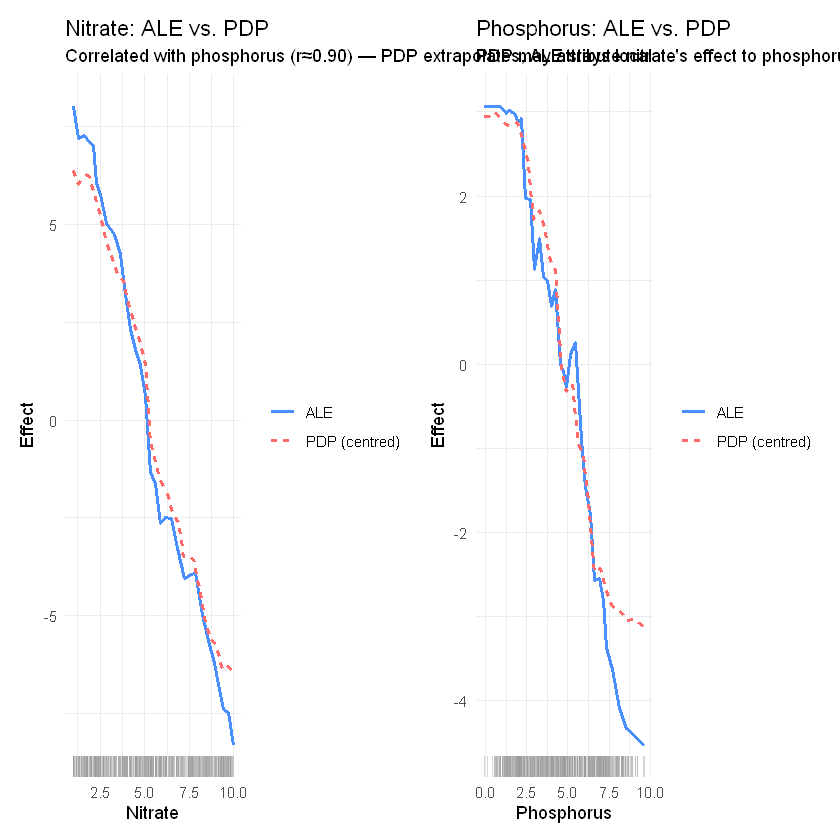

In [8]:
# ── ALE via iml ──────────────────────────────────────────────────────────────
ale_nitrate <- iml::FeatureEffect$new(
  predictor, feature = "nitrate",
  method = "ale", grid.size = 30
)

ale_phos <- iml::FeatureEffect$new(
  predictor, feature = "phosphorus",
  method = "ale", grid.size = 30
)

# ── PDP via pdp ───────────────────────────────────────────────────────────────
pdp_nitrate <- pdp::partial(
  rf_fit, pred.var = "nitrate", train = ale_data, grid.resolution = 30
)
pdp_phos <- pdp::partial(
  rf_fit, pred.var = "phosphorus", train = ale_data, grid.resolution = 30
)

# Check actual column names from iml output
cat("ALE nitrate columns:", names(ale_nitrate$results), "\n")
cat("ALE phos columns:",    names(ale_phos$results), "\n")

# Centre PDP to same scale as ALE for comparison
centre <- function(x) x - mean(x)

# iml ALE results: feature column named after the feature, effect in ".value"
ale_nit_df <- ale_nitrate$results %>%
  as_tibble() %>%
  dplyr::rename(x = nitrate, ale = .value) %>%
  dplyr::mutate(method = "ALE")

pdp_nit_df <- as_tibble(pdp_nitrate) %>%
  dplyr::rename(x = nitrate, ale = yhat) %>%
  dplyr::mutate(ale = centre(ale), method = "PDP (centred)")

p_nit <- bind_rows(ale_nit_df, pdp_nit_df) %>%
  ggplot(aes(x = x, y = ale, color = method, linetype = method)) +
  geom_line(linewidth = 1.1) +
  geom_rug(data = ale_data, aes(x = nitrate, y = NULL), color = "gray60",
           sides = "b", alpha = 0.4, inherit.aes = FALSE) +
  scale_color_manual(values = c(ALE = "#4a8fff", "PDP (centred)" = "#ff6b6b")) +
  labs(title    = "Nitrate: ALE vs. PDP",
       subtitle = "Correlated with phosphorus (r≈0.90) — PDP extrapolates; ALE stays local",
       x = "Nitrate", y = "Effect", color = NULL, linetype = NULL) +
  theme_minimal()

ale_phos_df <- ale_phos$results %>%
  as_tibble() %>%
  dplyr::rename(x = phosphorus, ale = .value) %>%
  dplyr::mutate(method = "ALE")

pdp_phos_df <- as_tibble(pdp_phos) %>%
  dplyr::rename(x = phosphorus, ale = yhat) %>%
  dplyr::mutate(ale = centre(ale), method = "PDP (centred)")

p_phos <- bind_rows(ale_phos_df, pdp_phos_df) %>%
  ggplot(aes(x = x, y = ale, color = method, linetype = method)) +
  geom_line(linewidth = 1.1) +
  geom_rug(data = ale_data, aes(x = phosphorus, y = NULL), color = "gray60",
           sides = "b", alpha = 0.4, inherit.aes = FALSE) +
  scale_color_manual(values = c(ALE = "#4a8fff", "PDP (centred)" = "#ff6b6b")) +
  labs(title    = "Phosphorus: ALE vs. PDP",
       subtitle = "PDP may attribute nitrate's effect to phosphorus due to correlation",
       x = "Phosphorus", y = "Effect", color = NULL, linetype = NULL) +
  theme_minimal()

(p_nit | p_phos)

---

## 2D ALE: Interaction Effects

Warning message in merge.data.table(deltas, interval_grid, on = c(".interval1", :
"Unknown argument 'on' has been passed."
Warning message in merge.data.table(ale, cell.counts.m, on = c(".interval1", ".interval2"), :
"Unknown argument 'on' has been passed."


2D ALE columns: .type .ale .right .left .bottom .top nitrate water_qual 


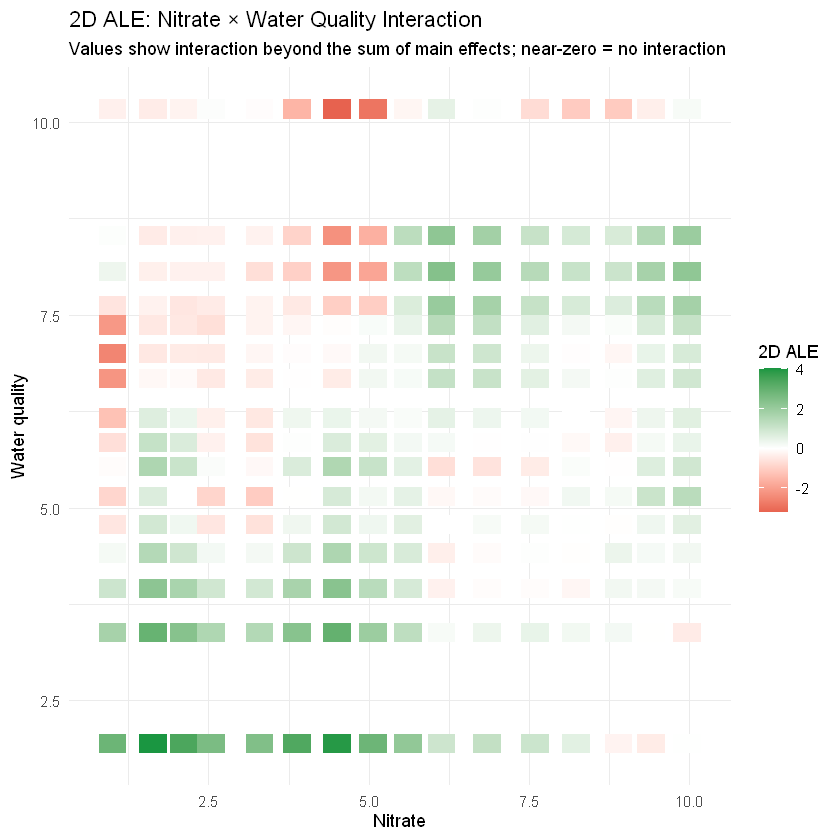

In [14]:
# Create 2D ALE object
ale_2d <- iml::FeatureEffect$new(
  predictor,
  feature   = c("nitrate", "water_qual"),
  method    = "ale",
  grid.size = 15
)

cat("2D ALE columns:", names(ale_2d$results), "\n")

ale_2d_df <- ale_2d$results %>% as_tibble()

ggplot(ale_2d_df, aes(x = nitrate, y = water_qual, fill = .ale)) +
  geom_tile() +
  scale_fill_gradient2(
    low      = "#d73027", mid = "white", high = "#1a9641",
    midpoint = 0, name = "2D ALE"
  ) +
  labs(
    title    = "2D ALE: Nitrate × Water Quality Interaction",
    subtitle = "Values show interaction beyond the sum of main effects; near-zero = no interaction",
    x = "Nitrate", y = "Water quality"
  ) +
  theme_minimal()

---

## ALE Plots for All Features

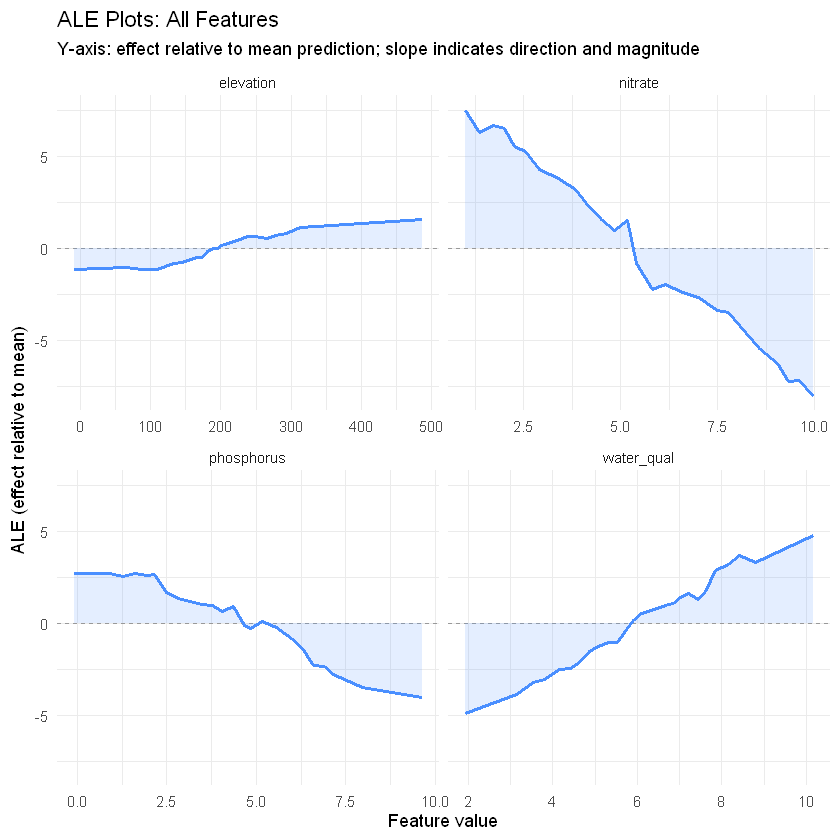

In [15]:
feat_cols <- c("nitrate","phosphorus","water_qual","elevation")

ale_all <- map(feat_cols, function(feat) {
  eff <- iml::FeatureEffect$new(
    predictor, feature=feat, method="ale", grid.size=25
  )
  eff$results %>%
    as_tibble() %>%
    rename(x=all_of(feat), ale=.value) %>%
    mutate(feature=feat)
}) %>% bind_rows()

ggplot(ale_all, aes(x=x, y=ale)) +
  geom_hline(yintercept=0, linetype="dashed", color="gray60") +
  geom_line(color="#4a8fff", linewidth=1) +
  geom_ribbon(aes(ymin=0, ymax=ale),
              fill="#4a8fff", alpha=0.15) +
  facet_wrap(~feature, scales="free_x", ncol=2) +
  labs(
    title    = "ALE Plots: All Features",
    subtitle = "Y-axis: effect relative to mean prediction; slope indicates direction and magnitude",
    x="Feature value", y="ALE (effect relative to mean)"
  ) +
  theme_minimal()

---

## Common Pitfalls

**1. Using PDPs when features are correlated and concluding ALE is unnecessary**  
The bias in PDPs from correlated features is silent — the plot looks perfectly normal; there is no visual indicator that the curve reflects unrealistic data combinations. For any dataset where predictors have |r| > 0.5, always compare ALE and PDP and report the difference. If they agree, correlation did not bias the PDP. If they disagree substantially, report ALE.

**2. Interpreting ALE y-axis values as predicted responses**  
ALE values are centred effects — they represent deviations from the mean prediction, not the prediction itself. An ALE of +3 for nitrate=8 means: near this value, the prediction is about 3 units above the average prediction, not that the predicted richness is 3. Always label the y-axis clearly as "effect relative to mean" and state the mean prediction separately.

**3. Computing ALE on sparse regions of the feature distribution**  
ALE uses local differences within narrow intervals. In sparse regions (e.g. tails of the distribution), intervals contain few observations and the estimated local effect is noisy. Always overlay a rug plot of observed values and interpret ALE estimates in data-sparse regions with caution.

**4. Using 2D ALE to infer interaction strength without a formal test**  
A 2D ALE plot that appears non-flat does not confirm a statistically significant interaction — it may reflect noise in sparse cells. For formal interaction testing, use the H-statistic (`iml::Interaction$new()`) which provides a summary statistic for the proportion of variance explained by interactions.

**5. Applying ALE to linear models and expecting different results from PDPs**  
For linear models, ALE and PDP produce identical results — the linearity means local and global effects are the same, and there is no extrapolation bias. ALE provides its largest advantage over PDPs for non-linear, tree-based models with correlated features.

---
*r_methods_library · Samantha McGarrigle · [github.com/samantha-mcgarrigle](https://github.com/samantha-mcgarrigle)*